Site para baixar a base de dados: http://dados.recife.pe.gov.br/dataset/situacao-final-dos-alunos-por-periodo-letivo/resource/9afdd9e1-9bc2-4d40-a070-4dec351d6e0f

Colab da professora: https://colab.research.google.com/drive/1wCnFJBdIEiu8I7Euc9PB4Iwax1aIpCxu?usp=sharing#scrollTo=QJqgy6lKfk2o

In [ ]:
!wget -q !wget -q https://dlcdn.apache.org/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz
!tar xf spark-3.4.1-bin-hadoop3.tgz
!pip install -q findspark
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.0-py2.py3-none-any.whl size=317425344 sha256=462cde94cafb727e8fe92e1953fcd380a075c232f9af4d8ede201227ff8f016f
  Stored in directory: /root/.cache/pip/wheels/41/4e/10/c2cf2467f71c678cfc8a6b9ac9241e5e44a01940da8fbb17fc
Successfully built pyspark


In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.4.1-bin-hadoop3"
import findspark
findspark.init()
from pyspark.sql.functions import count, col, when
from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from pyspark.sql import SparkSession
sc = SparkSession.builder.master('local[*]').getOrCreate()

In [ ]:
data = sc.read.csv("/content/situacaofinalalunos2022.csv", header = True, sep = ";", inferSchema=True)

In [ ]:
df = data
df.show()

+----+------------+----------+------------+----------+----------+------+-------+---------+----------+-----------------+-----+----------+--------+---------+----+--------------------+
| ano|  nescolnome|ebairrnome|  eescolruae|aescolnume|cescolrpae|modens|compens|anoensino|esermodesc|       nmodennome|turma|nturesnome|     mat|alunosexo|situ|          esitaldesc|
+----+------------+----------+------------+----------+----------+------+-------+---------+----------+-----------------+-----+----------+--------+---------+----+--------------------+
|2022|ABILIO GOMES|BOA VIAGEM|BRUNO VELOZO|       S/N|         6|     0|      5|  GRUPO V|   GRUPO V|EDUCACAO INFANTIL|    A|     MANHÃ|20068166|        M|  AP|            APROVADO|
|2022|ABILIO GOMES|BOA VIAGEM|BRUNO VELOZO|       S/N|         6|     0|      5|  GRUPO V|   GRUPO V|EDUCACAO INFANTIL|    A|     MANHÃ|21610452|        F|  TR|TR DUR ANO FORA REDE|
|2022|ABILIO GOMES|BOA VIAGEM|BRUNO VELOZO|       S/N|         6|     0|      5|  GRUPO V|

In [ ]:
df.columns

['ano',
 'nescolnome',
 'ebairrnome',
 'eescolruae',
 'aescolnume',
 'cescolrpae',
 'modens',
 'compens',
 'anoensino',
 'esermodesc',
 'nmodennome',
 'turma',
 'nturesnome',
 'mat',
 'alunosexo',
 'situ',
 'esitaldesc']

In [ ]:
df.dtypes

[('ano', 'int'),
 ('nescolnome', 'string'),
 ('ebairrnome', 'string'),
 ('eescolruae', 'string'),
 ('aescolnume', 'string'),
 ('cescolrpae', 'int'),
 ('modens', 'int'),
 ('compens', 'string'),
 ('anoensino', 'string'),
 ('esermodesc', 'string'),
 ('nmodennome', 'string'),
 ('turma', 'string'),
 ('nturesnome', 'string'),
 ('mat', 'int'),
 ('alunosexo', 'string'),
 ('situ', 'string'),
 ('esitaldesc', 'string')]

In [ ]:
numero_de_linhas = df.count()

print(f'Número de linhas do DataFrame: {numero_de_linhas}')

Número de linhas do DataFrame: 97260


In [ ]:
df = df.withColumnRenamed('ano', 'Ano')
df = df.withColumnRenamed('nescolnome', 'Escola')
df = df.withColumnRenamed('ebairrnome', 'Bairro')
df = df.withColumnRenamed('eescolruae', 'Logradouro')
df = df.withColumnRenamed('aescolnume', 'Numero')
df = df.withColumnRenamed('cescolrpae', 'CodigoRegiao')
df = df.withColumnRenamed('modens', 'ModeloEnsino')
df = df.withColumnRenamed('anoensino', 'AnoEnsino')
df = df.withColumnRenamed('esermodesc', 'ModalidadeEnsino')
df = df.withColumnRenamed('nmodennome', 'NomeModalidadeEnsino')
df = df.withColumnRenamed('turma', 'Turma')
df = df.withColumnRenamed('nturesnome', 'Turno')
df = df.withColumnRenamed('mat', 'Matricula')
df = df.withColumnRenamed('alunosexo', 'Sexo')
df = df.withColumnRenamed('situ', 'Situacao')
df = df.withColumnRenamed('esitaldesc', 'SituacaoDescricao')

df.show(7, truncate=False)

+----+------------+----------+------------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+--------------------+
|Ano |Escola      |Bairro    |Logradouro  |Numero|CodigoRegiao|ModeloEnsino|compens|AnoEnsino|ModalidadeEnsino|NomeModalidadeEnsino|Turma|Turno|Matricula|Sexo|Situacao|SituacaoDescricao   |
+----+------------+----------+------------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+--------------------+
|2022|ABILIO GOMES|BOA VIAGEM|BRUNO VELOZO|S/N   |6           |0           |5      |GRUPO V  |GRUPO V         |EDUCACAO INFANTIL   |A    |MANHÃ|20068166 |M   |AP      |APROVADO            |
|2022|ABILIO GOMES|BOA VIAGEM|BRUNO VELOZO|S/N   |6           |0           |5      |GRUPO V  |GRUPO V         |EDUCACAO INFANTIL   |A    |MANHÃ|21610452 |F   |TR      |TR DUR ANO FORA REDE|
|2022|ABILIO GOMES|BOA VIAGEM|BRUNO VELOZO|S/N   |

In [ ]:
for columns in df:
  print(df.select(columns).distinct().show())

+----+
| Ano|
+----+
|2022|
+----+

None
+--------------------+
|              Escola|
+--------------------+
|DIACONO ABEL GUEIROS|
|            DO PILAR|
|           ESPERANCA|
|ALTO JARDIM PROGR...|
|   MAEZINHA DO COQUE|
|      IBURA DE BAIXO|
|ARTISTA PLASTICO ...|
|           DO JORDAO|
|     LAGOA ENCANTADA|
|     MONTEIRO LOBATO|
|DONA CARMELITA MU...|
|            LUA LUAR|
|OCTAVIO DE MEIRA ...|
|   ALTO DA GUABIRABA|
|        DOS REMEDIOS|
|GOVERNADOR MIGUEL...|
|     MUNDO ESPERANCA|
|  ANITA PAES BARRETO|
|ENGENHEIRO EDINAL...|
|IRMA TEREZINHA BA...|
+--------------------+
only showing top 20 rows

None
+------------------+
|            Bairro|
+------------------+
|  JARDIM SAO PAULO|
|           TORROES|
|CAMPINA DO BARRETO|
|  SITIO DOS PINTOS|
|             BARRO|
|          BEBERIBE|
|         MANGUEIRA|
|             COHAB|
|       SANTO AMARO|
|ALTO JOSE DO PINHO|
|            SANCHO|
|            FUNDAO|
|          CAJUEIRO|
|            RECIFE|
|          CORDEIRO

In [ ]:
sexo_3 = df.filter(col('Sexo') == 3).show(truncate=False)

+----+----------------------------------+-------+------------+------+------------+------------+-------+---------+----------------+--------------------------+-----+-----+---------+----+--------+--------------------+
|Ano |Escola                            |Bairro |Logradouro  |Numero|CodigoRegiao|ModeloEnsino|compens|AnoEnsino|ModalidadeEnsino|NomeModalidadeEnsino      |Turma|Turno|Matricula|Sexo|Situacao|SituacaoDescricao   |
+----+----------------------------------+-------+------------+------+------------+------------+-------+---------+----------------+--------------------------+-----+-----+---------+----+--------+--------------------+
|2022|ALMIRANTE SOARES DUTRA            |CABANGA|CAMUTANGA   |180   |1           |0           |4      |GRUPO IV |GRUPO IV        |EDUCACAO INFANTIL         |B    |TARDE|22053387 |3   |TR      |TR DUR ANO FORA REDE|
|2022|DEPUTADO EDSON CANTARELLI         |IBURA  |RUBINEIA    |49    |6           |9           |3      |MÓDULO 3 |MÓDULO 3        |EDUCACAO  

In [ ]:
modalidade_null = df.filter(col('ModalidadeEnsino').isNull()).show(truncate=False)

+----+-----------------------------------+----------+---------------------------------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+--------------------+
|Ano |Escola                             |Bairro    |Logradouro                       |Numero|CodigoRegiao|ModeloEnsino|compens|AnoEnsino|ModalidadeEnsino|NomeModalidadeEnsino|Turma|Turno|Matricula|Sexo|Situacao|SituacaoDescricao   |
+----+-----------------------------------+----------+---------------------------------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+--------------------+
|2022|CRISTIANO CORDEIRO                 |COHAB     |SANTOS                           |S/N   |6           |1           |null   |5º ANO   |null            |ENSINO FUNDAMENTAL  |EB   |TARDE|17094615 |F   |TR      |TR DUR ANO FORA REDE|
|2022|CRISTIANO CORDEIRO                 |COHAB     |SANTOS     

In [ ]:
df_limpo = df.selectExpr("*")
df_limpo.show(truncate=False)

+----+------------+----------+------------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+--------------------+
|Ano |Escola      |Bairro    |Logradouro  |Numero|CodigoRegiao|ModeloEnsino|compens|AnoEnsino|ModalidadeEnsino|NomeModalidadeEnsino|Turma|Turno|Matricula|Sexo|Situacao|SituacaoDescricao   |
+----+------------+----------+------------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+--------------------+
|2022|ABILIO GOMES|BOA VIAGEM|BRUNO VELOZO|S/N   |6           |0           |5      |GRUPO V  |GRUPO V         |EDUCACAO INFANTIL   |A    |MANHÃ|20068166 |M   |AP      |APROVADO            |
|2022|ABILIO GOMES|BOA VIAGEM|BRUNO VELOZO|S/N   |6           |0           |5      |GRUPO V  |GRUPO V         |EDUCACAO INFANTIL   |A    |MANHÃ|21610452 |F   |TR      |TR DUR ANO FORA REDE|
|2022|ABILIO GOMES|BOA VIAGEM|BRUNO VELOZO|S/N   |

In [ ]:
df_limpo = df_limpo.filter(col('Sexo') == 3).show(truncate=False)

+----+----------------------------------+-------+------------+------+------------+------------+-------+---------+----------------+--------------------------+-----+-----+---------+----+--------+--------------------+
|Ano |Escola                            |Bairro |Logradouro  |Numero|CodigoRegiao|ModeloEnsino|compens|AnoEnsino|ModalidadeEnsino|NomeModalidadeEnsino      |Turma|Turno|Matricula|Sexo|Situacao|SituacaoDescricao   |
+----+----------------------------------+-------+------------+------+------------+------------+-------+---------+----------------+--------------------------+-----+-----+---------+----+--------+--------------------+
|2022|ALMIRANTE SOARES DUTRA            |CABANGA|CAMUTANGA   |180   |1           |0           |4      |GRUPO IV |GRUPO IV        |EDUCACAO INFANTIL         |B    |TARDE|22053387 |3   |TR      |TR DUR ANO FORA REDE|
|2022|DEPUTADO EDSON CANTARELLI         |IBURA  |RUBINEIA    |49    |6           |9           |3      |MÓDULO 3 |MÓDULO 3        |EDUCACAO  

In [ ]:
df_limpo = df_limpo.filter(col('Sexo') != 3)
df_limpo.show(truncate=False)

AttributeError: ignored

In [ ]:
df_limpo = df_limpo.filter(col('Sexo') == 3).show(truncate=False)

AttributeError: ignored

In [ ]:
df_limpo = df.selectExpr("*").filter(col('ModalidadeEnsino').isNull())
df_limpo.show(truncate=False)

+----+-----------------------------------+----------+---------------------------------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+--------------------+
|Ano |Escola                             |Bairro    |Logradouro                       |Numero|CodigoRegiao|ModeloEnsino|compens|AnoEnsino|ModalidadeEnsino|NomeModalidadeEnsino|Turma|Turno|Matricula|Sexo|Situacao|SituacaoDescricao   |
+----+-----------------------------------+----------+---------------------------------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+--------------------+
|2022|CRISTIANO CORDEIRO                 |COHAB     |SANTOS                           |S/N   |6           |1           |null   |5º ANO   |null            |ENSINO FUNDAMENTAL  |EB   |TARDE|17094615 |F   |TR      |TR DUR ANO FORA REDE|
|2022|CRISTIANO CORDEIRO                 |COHAB     |SANTOS     

In [ ]:
from pyspark.sql.functions import when

df_limpo = df.withColumn('ModalidadeEnsino', when(col('ModalidadeEnsino').isNull(), 'NAO INFORMADO').otherwise(col('ModalidadeEnsino')))

df_limpo.show(truncate=False)

+----+------------+----------+------------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+--------------------+
|Ano |Escola      |Bairro    |Logradouro  |Numero|CodigoRegiao|ModeloEnsino|compens|AnoEnsino|ModalidadeEnsino|NomeModalidadeEnsino|Turma|Turno|Matricula|Sexo|Situacao|SituacaoDescricao   |
+----+------------+----------+------------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+--------------------+
|2022|ABILIO GOMES|BOA VIAGEM|BRUNO VELOZO|S/N   |6           |0           |5      |GRUPO V  |GRUPO V         |EDUCACAO INFANTIL   |A    |MANHÃ|20068166 |M   |AP      |APROVADO            |
|2022|ABILIO GOMES|BOA VIAGEM|BRUNO VELOZO|S/N   |6           |0           |5      |GRUPO V  |GRUPO V         |EDUCACAO INFANTIL   |A    |MANHÃ|21610452 |F   |TR      |TR DUR ANO FORA REDE|
|2022|ABILIO GOMES|BOA VIAGEM|BRUNO VELOZO|S/N   |

In [ ]:
modalidade_null = df_limpo.filter(col('ModalidadeEnsino').isNull()).show(truncate=False)

+---+------+------+----------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+-----------------+
|Ano|Escola|Bairro|Logradouro|Numero|CodigoRegiao|ModeloEnsino|compens|AnoEnsino|ModalidadeEnsino|NomeModalidadeEnsino|Turma|Turno|Matricula|Sexo|Situacao|SituacaoDescricao|
+---+------+------+----------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+-----------------+
+---+------+------+----------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+-----------------+



In [ ]:
resultados_filtro = df_limpo.filter((col('NomeModalidadeEnsino') == 'ENSINO FUNDAMENTAL') & (col('SituacaoDescricao') == 'REPROV P/  FALTA')).show(truncate=False)

+----+---------------------------------+-------------------+---------------------------------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+-----------------+
|Ano |Escola                           |Bairro             |Logradouro                       |Numero|CodigoRegiao|ModeloEnsino|compens|AnoEnsino|ModalidadeEnsino|NomeModalidadeEnsino|Turma|Turno|Matricula|Sexo|Situacao|SituacaoDescricao|
+----+---------------------------------+-------------------+---------------------------------+------+------------+------------+-------+---------+----------------+--------------------+-----+-----+---------+----+--------+-----------------+
|2022|ALDA ROMEU                       |AGUA FRIA          |CORREGO DO DEODATO               |685   |2           |1           |4      |5º ANO   |5º ANO          |ENSINO FUNDAMENTAL  |A    |MANHÃ|22643850 |M   |RF      |REPROV P/  FALTA |
|2022|ANDRE DE MELO                    |ESTANCIA

In [ ]:
contagem = df_limpo.filter((col('NomeModalidadeEnsino') == 'ENSINO FUNDAMENTAL') & (col('SituacaoDescricao') == 'REPROV P/  FALTA')).count()

print(f"Número de linhas após o filtro: {contagem}")

Número de linhas após o filtro: 252


In [ ]:
contagem2 = df_limpo.filter((col('SituacaoDescricao') == 'REPROV P/  FALTA')).count()

print(f"Número de linhas após o filtro: {contagem2}")

Número de linhas após o filtro: 444


Em torno de 252 alunos do ensino fundamental foram reprovados por falta no ano de 2022.
Se torna um número pequeno se compararmos a 97260, mas se percebemos que do total de reprovados (444), 252 corresponde a quase 57%. Se torna um pontinho de atenção aí.

In [ ]:
contagem3 = df_limpo.filter((col('SituacaoDescricao') == 'FALECIDO')).count()

print(f"Número de linhas após o filtro: {contagem3}")

Número de linhas após o filtro: 52


## Processamento e Análise Descritiva Com Pandas

In [ ]:
df_pandas = df_limpo.toPandas()

In [ ]:
df_pandas

,Ano,Escola,Bairro,Logradouro,Numero,CodigoRegiao,ModeloEnsino,compens,AnoEnsino,ModalidadeEnsino,NomeModalidadeEnsino,Turma,Turno,Matricula,Sexo,Situacao,SituacaoDescricao
0,2022,ABILIO GOMES,BOA VIAGEM,BRUNO VELOZO,S/N,6,0,5,GRUPO V,GRUPO V,EDUCACAO INFANTIL,A,MANHÃ,20068166,M,6,APROVADO
1,2022,ABILIO GOMES,BOA VIAGEM,BRUNO VELOZO,S/N,6,0,5,GRUPO V,GRUPO V,EDUCACAO INFANTIL,A,MANHÃ,21610452,F,9,TR DUR ANO FORA REDE
2,2022,ABILIO GOMES,BOA VIAGEM,BRUNO VELOZO,S/N,6,0,5,GRUPO V,GRUPO V,EDUCACAO INFANTIL,A,MANHÃ,22150900,F,6,APROVADO
3,2022,ABILIO GOMES,BOA VIAGEM,BRUNO VELOZO,S/N,6,0,5,GRUPO V,GRUPO V,EDUCACAO INFANTIL,A,MANHÃ,22113339,M,6,APROVADO
4,2022,ABILIO GOMES,BOA VIAGEM,BRUNO VELOZO,S/N,6,0,5,GRUPO V,GRUPO V,EDUCACAO INFANTIL,A,MANHÃ,22015973,F,6,APROVADO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97255,2022,27 DE NOVEMBRO,COHAB,DOZE DE JUNHO,1120,6,1,4,5º ANO,5º ANO,ENSINO FUNDAMENTAL,B,TARDE,20121016,M,6,APROVADO
97256,2022,27 DE NOVEMBRO,COHAB,DOZE DE JUNHO,1120,6,1,4,5º ANO,5º ANO,ENSINO FUNDAMENTAL,B,TARDE,21011699,F,6,APROVADO
97257,2022,27 DE NOVEMBRO,COHAB,DOZE DE JUNHO,1120,6,1,4,5º ANO,5º ANO,ENSINO FUNDAMENTAL,B,TARDE,21069603,M,6,APROVADO
97258,2022,27 DE NOVEMBRO,COHAB,DOZE DE JUNHO,1120,6,1,4,5º ANO,5º ANO,ENSINO FUNDAMENTAL,B,TARDE,13250400,F,6,APROVADO


In [ ]:
df_pandas.dtypes

Ano                      int32
Escola                  object
Bairro                  object
Logradouro              object
Numero                  object
CodigoRegiao             int32
ModeloEnsino             int32
compens                 object
AnoEnsino               object
ModalidadeEnsino        object
NomeModalidadeEnsino    object
Turma                   object
Turno                   object
Matricula                int32
Sexo                    object
Situacao                 int64
SituacaoDescricao       object
dtype: object

In [ ]:
# Importar matplotlib.
import matplotlib.pyplot as plt
# Importar seaborn.
import seaborn as sns

In [ ]:
# Trocando os dados para números

df_pandas.loc[df_pandas['Situacao'] == 'RF', 'Situacao'] = '1'
df_pandas.loc[df_pandas['Situacao'] == 'RN', 'Situacao'] = '2'
df_pandas.loc[df_pandas['Situacao'] == 'MO', 'Situacao'] = '3'
df_pandas.loc[df_pandas['Situacao'] == 'RT', 'Situacao'] = '4'
df_pandas.loc[df_pandas['Situacao'] == 'FA', 'Situacao'] = '5'
df_pandas.loc[df_pandas['Situacao'] == 'AP', 'Situacao'] = '6'
df_pandas.loc[df_pandas['Situacao'] == 'D', 'Situacao'] = '7'
df_pandas.loc[df_pandas['Situacao'] == 'TA', 'Situacao'] = '8'
df_pandas.loc[df_pandas['Situacao'] == 'TR', 'Situacao'] = '9'

In [ ]:
# Convertendo a coluna para inteiro para coseguir fazer gráficos
df_pandas['Situacao'] = df_pandas['Situacao'].astype(int)

### LEGENDA DA TROCA:

1 - RF - REPROV P/ FALTA  
2 - RN - RENV S/SIT FINAL DEF - Remanejado sem situação final definida.  
3 - MO - REMANEJADO  
4 - RT - RETIDO  
5 - FA - FALECIDO  
6 - AP - APROVADO  
7 - D - DESIST/DEIXOU FREQUE   
8 - TA - TR DUR ANO FORA REDE - Transferido durante o ano, fora da rede de ensino.  
9 -TR - TR DUR ANO P/REDE - Transferido durante o ano para a rede de ensino.  

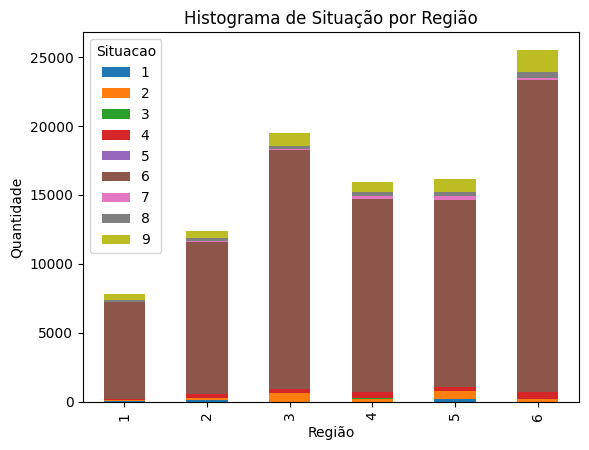

In [ ]:
histograma = df_pandas.groupby(['CodigoRegiao', 'Situacao']).size().unstack()

histograma.plot(kind='bar', stacked=True)

plt.xlabel('Região')
plt.ylabel('Quantidade')
plt.title('Histograma de Situação por Região')

plt.show()

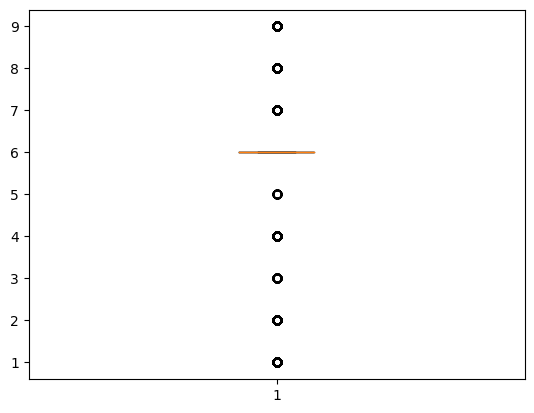

In [ ]:
plt.boxplot(df_pandas.Situacao)
plt.show()

# O resultado mais comum é o 6 que significa aprovado. Por isso todos os outros estão meio que "fora" do padrão

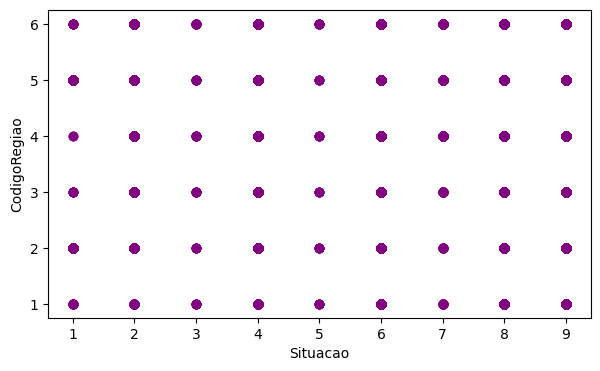

In [ ]:
# Plotando dispersão de dados = relacionando duas variáveis numéricas.
plt.figure(figsize = (7,4))
plt.scatter(
    df_pandas['Situacao'],
    df_pandas['CodigoRegiao'],
    color='purple')

plt.xlabel("Situacao")
plt.ylabel("CodigoRegiao")
plt.show()

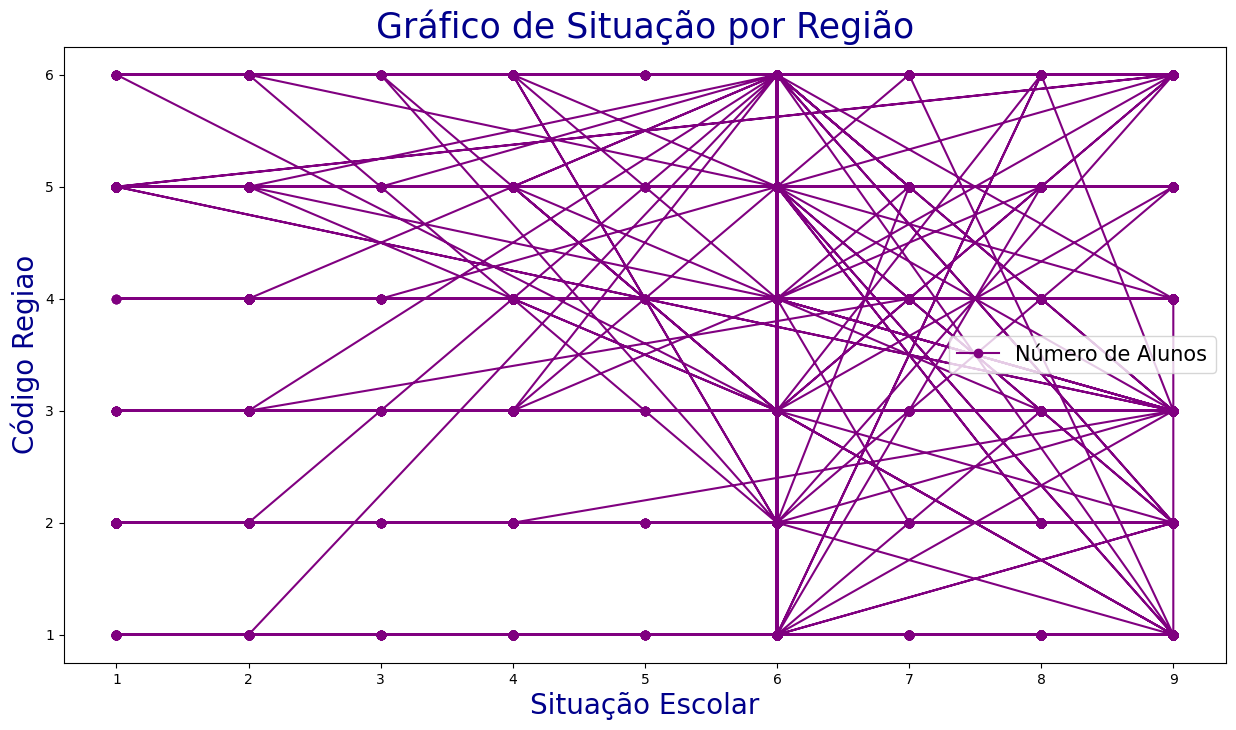

In [ ]:
# Esse gráfico ficou horroroso, mas foi engraçado fazer
plt.rcParams["figure.figsize"] = (15, 8)
plt.plot (df_pandas['Situacao'], df_pandas['CodigoRegiao'], color = 'purple', marker = 'o')

plt.title('Gráfico de Situação por Região',  fontsize = 25, color = 'darkblue')

plt.xlabel('Situação Escolar', fontsize = 20, color = 'darkblue')
plt.ylabel('Código Regiao',  fontsize = 20, color = 'darkblue')

plt.legend(['Número de Alunos'], loc = 'best', fontsize = 15)

In [ ]:
# Eu não tinha muito dado que poderia ser tranformado em numérico, sorry.

In [ ]:
# That's all folks - Sara Lopes